# generate_derived_solar_fields 模块验证

本 Notebook 用于验证：

- 数据预处理：将官方投影样例映射为修改后方法可读的 lat/lon 六维输入。
- 结果对比：在 notebook 中调用原方法与修改后方法，并与 KGO 做数值统计与可视化对比。

章节组织：

1. **投影坐标输入** — 预处理后仍用投影坐标运行
2. **经纬坐标输入** — 预处理将投影重网格到规则经纬后，原方法与修改后方法均在经纬网格上运行

投影坐标章节下，按方法（GenerateSolarTime / GenerateClearskySolarRadiation）再分为：

- 算法运行与数值对比
- **输入数据绘图**
- **输出对比绘图**

经纬坐标章节仅做算法运行与数值对比、输出对比绘图（输入场来自同一套投影官方样例的重网格，不再重复绘制输入图）。


## 环境准备

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import numpy as np
import xarray as xr
import iris

# 绘图显示设置：中文字体、负号、默认图尺寸
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (14, 4)

# 将仓库根目录与 Improver 参考副本加入 import 路径
ROOT_DIR = Path.cwd().resolve().parents[1]
for _p in (ROOT_DIR, ROOT_DIR / "improver-1.18.7"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

# 旧版 Improver clearsky 积分仍可能调用 np.trapz
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

# 修改后方法
from generate_derived_solar_fields.src.generate_derived_solar_fields import (
    GenerateSolarTime,
    GenerateClearskySolarRadiation,
)

# 原方法（Iris Cube 接口）
from improver.generate_ancillaries.generate_derived_solar_fields import (  # pyright: ignore[reportMissingImports]
    GenerateSolarTime as OrigGenerateSolarTime,
    GenerateClearskySolarRadiation as OrigGenerateClearskySolarRadiation,
)


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 投影坐标输入

### 1. 数据预处理


In [2]:
# 官方测试数据根目录
TEST_ROOT = ROOT_DIR / "generate_derived_solar_fields" / "test_data"


def load_primary_dataarray(nc_path: Path) -> xr.DataArray:
    """读取 netCDF 主变量，跳过投影定义与 bounds 变量。"""
    ds = xr.open_dataset(nc_path, decode_timedelta=False)
    ignore_vars = {
        "albers_conical_equal_area",
        "time_bnds",
        "projection_y_coordinate_bnds",
        "projection_x_coordinate_bnds",
    }
    candidates = [
        name for name in ds.data_vars if name not in ignore_vars and not name.endswith("_bnds")
    ]
    if not candidates:
        ds.close()
        raise ValueError(f"未找到主变量: {nc_path}")
    da = ds[candidates[0]].load()

    # 将投影定义序列化到主变量 attrs，供 CLI 读取六维 nc 时直接解析。
    grid_mapping_name = da.attrs.get("grid_mapping")
    if isinstance(grid_mapping_name, str) and grid_mapping_name in ds.variables:
        mapping_attrs_raw = dict(ds[grid_mapping_name].attrs)
        mapping_attrs_json_ready = {}
        for key, value in mapping_attrs_raw.items():
            if isinstance(value, np.ndarray):
                mapping_attrs_json_ready[key] = value.tolist()
            elif isinstance(value, np.generic):
                mapping_attrs_json_ready[key] = value.item()
            else:
                mapping_attrs_json_ready[key] = value
        da.attrs["grid_mapping_attrs"] = json.dumps(
            mapping_attrs_json_ready, ensure_ascii=False
        )

    ds.close()
    return da


def _extract_projected_spatial_2d(da: xr.DataArray) -> xr.DataArray:
    """提取二维空间场，并将投影维名统一映射为 lat/lon。"""
    arr = da
    # 除空间维外，其余维度都取第一个切片
    for dim in list(arr.dims):
        if dim not in ("projection_y_coordinate", "projection_x_coordinate", "lat", "lon"):
            arr = arr.isel({dim: 0}, drop=True)

    # 将投影坐标维名映射成修改后方法可识别的 lat/lon
    rename_map = {}
    if "projection_y_coordinate" in arr.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in arr.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        arr = arr.rename(rename_map)

    # 强制维度顺序统一，避免后续拼装不一致
    if arr.dims != ("lat", "lon"):
        arr = arr.transpose("lat", "lon")
    return arr


def build_meb6d_from_projected(path: Path, *, name: str, time_value: str) -> xr.DataArray:
    """由投影样例构造修改后方法可读的 meb 六维输入。"""
    spatial = _extract_projected_spatial_2d(load_primary_dataarray(path))
    values = spatial.values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)
    units = str(spatial.attrs.get("units", "1"))

    attrs = {
        "model": "official_test_preprocessed",
        "dtime_units": "hour",
        "level_type": "surface",
        "time_type": "UT",
        "time_bounds": [0, 0],
        "units": units,
    }
    grid_mapping_attrs = spatial.attrs.get("grid_mapping_attrs")
    if not (isinstance(grid_mapping_attrs, str) and grid_mapping_attrs.strip()):
        raise ValueError("预处理失败：未找到 grid_mapping_attrs，无法识别投影坐标。")
    attrs["grid_mapping_attrs"] = grid_mapping_attrs

    lat_coord = spatial.coords["lat"].copy(deep=True)
    lon_coord = spatial.coords["lon"].copy(deep=True)

    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": np.array([0], dtype=np.int32),
            "level": np.array([0], dtype=np.int32),
            "time": np.array([np.datetime64(time_value)], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": lat_coord,
            "lon": lon_coord,
        },
        attrs=attrs,
        name=name,
    )


def to_2d_values(data: xr.DataArray) -> np.ndarray:
    """将 DataArray 统一提取为二维 numpy 数组（lat, lon）。"""
    arr = data
    if {"projection_y_coordinate", "projection_x_coordinate"}.issubset(set(arr.dims)):
        arr = _extract_projected_spatial_2d(arr)
    else:
        for dim in list(arr.dims):
            if dim not in ("lat", "lon"):
                arr = arr.isel({dim: 0}, drop=True)
        if arr.dims != ("lat", "lon"):
            arr = arr.transpose("lat", "lon")
    return arr.values.astype(np.float64)


def iris_cube_to_xr_spatial(cube, *, name=None) -> xr.DataArray:
    """将 Iris 二维空间 Cube 转为 xarray，供 compare_stats / 绘图使用。"""
    y_coord = cube.coord(axis="y")
    x_coord = cube.coord(axis="x")
    return xr.DataArray(
        np.asarray(cube.data, dtype=np.float32),
        dims=(y_coord.name(), x_coord.name()),
        coords={
            y_coord.name(): np.asarray(y_coord.points),
            x_coord.name(): np.asarray(x_coord.points),
        },
        name=name or (cube.name() or "field"),
        attrs={"units": str(cube.units)},
    )


def compare_stats(current: xr.DataArray, reference: xr.DataArray, tag: str):
    """打印三项误差指标，并返回 current/reference/diff 的二维数组。"""
    c = to_2d_values(current)
    r = to_2d_values(reference)
    if c.shape != r.shape:
        raise ValueError(f"二维场形状不一致: current={c.shape}, reference={r.shape}")
    diff = c - r
    print(
        f"[{tag}] mean_abs={np.mean(np.abs(diff)):.6f}, max_abs={np.max(np.abs(diff)):.6f}, rmse={np.sqrt(np.mean(diff**2)):.6f}"
    )
    return c, r, diff


def infer_accumulation_hours_from_kgo(kgo_path: Path) -> int:
    """从 KGO 的 time bounds 推断 accumulation_period（小时）。"""
    ds = xr.open_dataset(kgo_path, decode_timedelta=False)
    if "time_bnds" not in ds:
        ds.close()
        return 1
    b = ds["time_bnds"].values
    ds.close()
    if b.size < 2:
        return 1
    delta_hours = int((np.datetime64(b.reshape(-1)[1]) - np.datetime64(b.reshape(-1)[0])) / np.timedelta64(1, "h"))
    return max(delta_hours, 1)


In [3]:
# 两个官方样例子目录
from datetime import datetime

solar_root = TEST_ROOT / "generate-solar-time"
clearsky_root = TEST_ROOT / "generate-clearsky-solar-radiation"

# 从各自 KGO 自动读取有效时次，确保修改后方法与原方法/KGO对齐
solar_kgo_basic = load_primary_dataarray(solar_root / "basic" / "kgo.nc")
solar_valid_time = str(np.datetime_as_string(solar_kgo_basic.coords["time"].values, unit="s"))
solar_valid_time_dt = datetime.fromisoformat(solar_valid_time)

clearsky_kgo_basic = load_primary_dataarray(clearsky_root / "basic" / "kgo.nc")
clearsky_valid_time = str(np.datetime_as_string(clearsky_kgo_basic.coords["time"].values, unit="s"))
clearsky_valid_time_dt = datetime.fromisoformat(clearsky_valid_time)

# 预处理后的 target_grid：分别用于两个方法（修改后方法：meb 六维）
solar_target_grid = build_meb6d_from_projected(
    solar_root / "surface_altitude.nc", name="target_grid", time_value=solar_valid_time
)
clearsky_target_grid = build_meb6d_from_projected(
    clearsky_root / "surface_altitude.nc", name="target_grid", time_value=clearsky_valid_time
)

# 可选输入场：海拔与 Linke turbidity（clearsky 场景）
surface_altitude_meb = build_meb6d_from_projected(
    clearsky_root / "surface_altitude.nc", name="surface_altitude", time_value=clearsky_valid_time
)
linke_turbidity_meb = build_meb6d_from_projected(
    clearsky_root / "linke_turbidity.nc", name="linke_turbidity", time_value=clearsky_valid_time
)

# 原方法输入：直接读取官方投影 Iris Cube（与 meb 六维同源样例）
solar_target_cube = iris.load_cube(str(solar_root / "surface_altitude.nc"))
clearsky_target_cube = iris.load_cube(str(clearsky_root / "surface_altitude.nc"))
clearsky_altitude_cube = iris.load_cube(str(clearsky_root / "surface_altitude.nc"))
clearsky_linke_cube = iris.load_cube(str(clearsky_root / "linke_turbidity.nc"))

# 快速检查预处理后的形状与维度是否符合 meb 六维约定
print("solar_valid_time:", solar_valid_time)
print("clearsky_valid_time:", clearsky_valid_time)
print("solar_target_grid:", solar_target_grid.shape, solar_target_grid.dims)
print("clearsky_target_grid:", clearsky_target_grid.shape, clearsky_target_grid.dims)
print("surface_altitude_meb:", surface_altitude_meb.shape)
print("linke_turbidity_meb:", linke_turbidity_meb.shape)
print("solar_target_cube:", solar_target_cube.shape, solar_target_cube.name())
solar_target_grid


solar_valid_time: 2022-06-07T00:00:00
clearsky_valid_time: 2022-05-06T00:00:00
solar_target_grid: (1, 1, 1, 1, 103, 155) ('member', 'level', 'time', 'dtime', 'lat', 'lon')
clearsky_target_grid: (1, 1, 1, 1, 103, 155) ('member', 'level', 'time', 'dtime', 'lat', 'lon')
surface_altitude_meb: (1, 1, 1, 1, 103, 155)
linke_turbidity_meb: (1, 1, 1, 1, 103, 155)
solar_target_cube: (103, 155) surface_altitude


<xarray.DataArray 'target_grid' (member: 1, level: 1, time: 1, dtime: 1,
                                 lat: 103, lon: 155)> Size: 64kB
array([[[[[[  0.      ,   0.      ,   0.      , ...,   0.      ,
              0.      ,   0.      ],
           [  0.      ,   0.      ,   0.      , ...,   0.      ,
              0.      ,   0.      ],
           [  0.      ,   0.      ,   0.      , ...,   0.      ,
              0.      ,   0.      ],
           ...,
           [106.5201  , 127.87813 , 108.51654 , ...,   0.      ,
              0.      ,   0.      ],
           [106.10584 , 184.68294 , 104.72768 , ...,   0.      ,
              0.      ,   0.      ],
           [121.531364, 168.95259 , 161.75531 , ...,   0.      ,
              0.      ,   0.      ]]]]]],
      shape=(1, 1, 1, 1, 103, 155), dtype=float32)
Coordinates:
  * member   (member) int32 4B 0
  * level    (level) int32 4B 0
  * time     (time) datetime64[ns] 8B 2022-06-07
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float32 412B -4.736e+06 -4.726e+06 ... -3.766e+06 -3.757e+06
  * lon      (lon) float32 620B 5.12e+05 5.216e+05 ... 1.981e+06 1.99e+06
Attributes:
    model:               official_test_preprocessed
    dtime_units:         hour
    level_type:          surface
    time_type:           UT
    time_bounds:         [0, 0]
    units:               m
    grid_mapping_attrs:  {"grid_mapping_name": "albers_conical_equal_area", "...

### 2. GenerateSolarTime


#### 2.1 算法运行与数值对比


In [4]:
# 修改后方法调用（basic）
solar_current_basic = GenerateSolarTime().process(
    target_grid=solar_target_grid,
    time=solar_valid_time_dt,
)

# 参数行为检查：new_title 透传到输出 attrs
solar_current_new_title = GenerateSolarTime().process(
    target_grid=solar_target_grid,
    time=solar_valid_time_dt,
    new_title="demo_new_title",
)
assert solar_current_new_title.attrs.get("title") == "demo_new_title"

# 原方法：在同一投影样例上现场调用（Iris Cube）
solar_original_basic = iris_cube_to_xr_spatial(
    OrigGenerateSolarTime().process(solar_target_cube, solar_valid_time_dt),
    name="solar_time",
)

# KGO（basic）
solar_kgo_basic = load_primary_dataarray(solar_root / "basic" / "kgo.nc")

c_solar, k_solar, d_solar_ck = compare_stats(
    solar_current_basic, solar_kgo_basic, "solar 修改后方法-KGO"
)
_, o_solar, d_solar_co = compare_stats(
    solar_current_basic, solar_original_basic, "solar 修改后方法-原方法"
)
_, _, d_solar_ok = compare_stats(
    solar_original_basic, solar_kgo_basic, "solar 原方法-KGO"
)


[solar 修改后方法-KGO] mean_abs=0.000000, max_abs=0.000002, rmse=0.000001
[solar 修改后方法-原方法] mean_abs=0.000000, max_abs=0.000002, rmse=0.000001
[solar 原方法-KGO] mean_abs=0.000000, max_abs=0.000000, rmse=0.000000


#### 2.2 输入数据绘图


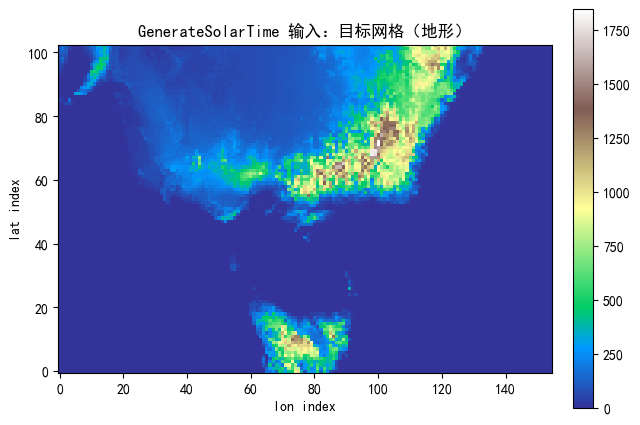

In [5]:
# 输入数据绘图：目标网格（地形）
solar_input_2d = to_2d_values(solar_target_grid)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.5))
im = ax.imshow(solar_input_2d, origin="lower", cmap="terrain")
ax.set_title("GenerateSolarTime 输入：目标网格（地形）")
ax.set_xlabel("lon index")
ax.set_ylabel("lat index")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


#### 2.3 输出对比绘图


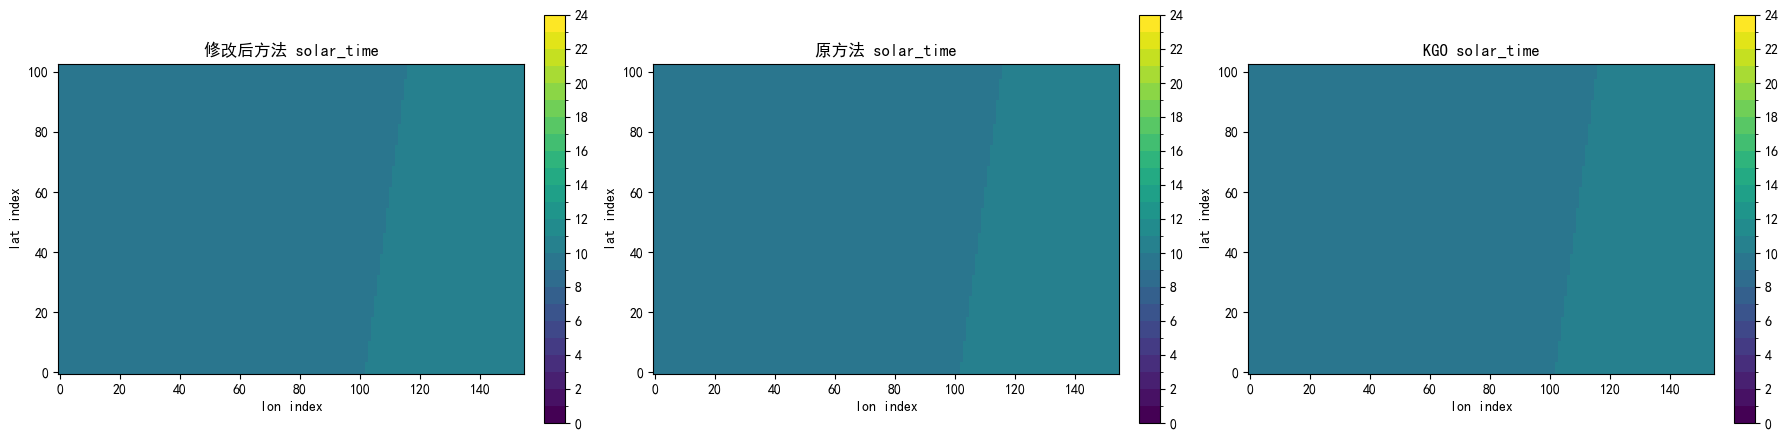

In [6]:
# 三图对比：修改后方法、原方法、KGO（固定 0-24 小时，每小时一档离散色标）
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

solar_bounds = np.arange(0, 25, 1, dtype=np.float32)
solar_cmap = plt.get_cmap("viridis", len(solar_bounds) - 1)
solar_norm = BoundaryNorm(solar_bounds, solar_cmap.N, clip=True)
solar_ticks = np.arange(0, 25, 2, dtype=np.int32)

im0 = axes[0].imshow(c_solar, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[0].set_title("修改后方法 solar_time")
axes[0].set_xlabel("lon index")
axes[0].set_ylabel("lat index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, ticks=solar_ticks)

im1 = axes[1].imshow(o_solar, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[1].set_title("原方法 solar_time")
axes[1].set_xlabel("lon index")
axes[1].set_ylabel("lat index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, ticks=solar_ticks)

im2 = axes[2].imshow(k_solar, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[2].set_title("KGO solar_time")
axes[2].set_xlabel("lon index")
axes[2].set_ylabel("lat index")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, ticks=solar_ticks)

plt.tight_layout()
plt.show()


### 3. GenerateClearskySolarRadiation


#### 3.1 算法运行与数值对比


In [7]:
acc_hours = infer_accumulation_hours_from_kgo(clearsky_root / "basic" / "kgo.nc")
print("inferred accumulation_period_hours:", acc_hours)

# 修改后方法调用（basic）
clearsky_current_basic = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
)

# 修改后方法调用（with_altitude_and_lt）
clearsky_current_with_alt_lt = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    surface_altitude=surface_altitude_meb,
    linke_turbidity=linke_turbidity_meb,
)

# 参数行为检查：new_title
clearsky_current_new_title = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours,
    new_title="demo_new_title",
)
assert clearsky_current_new_title.attrs.get("title") == "demo_new_title"

# 原方法：同一投影样例上现场调用
clearsky_original_basic = iris_cube_to_xr_spatial(
    OrigGenerateClearskySolarRadiation().process(
        target_grid=clearsky_target_cube,
        time=clearsky_valid_time_dt,
        accumulation_period=acc_hours,
    ),
    name="clearsky_solar_radiation",
)
# 原方法（with_altitude_and_lt）
clearsky_original_with_alt_lt = iris_cube_to_xr_spatial(
    OrigGenerateClearskySolarRadiation().process(
        target_grid=clearsky_target_cube,
        time=clearsky_valid_time_dt,
        accumulation_period=acc_hours,
        surface_altitude=clearsky_altitude_cube,
        linke_turbidity=clearsky_linke_cube,
    ),
    name="clearsky_solar_radiation",
)

# KGO
clearsky_kgo_basic = load_primary_dataarray(clearsky_root / "basic" / "kgo.nc")
clearsky_kgo_with_alt_lt = load_primary_dataarray(
    clearsky_root / "with_altitude_and_lt" / "kgo.nc"
)

c_clear_basic, k_clear_basic, d_clear_basic_ck = compare_stats(
    clearsky_current_basic, clearsky_kgo_basic, "clearsky basic 修改后方法-KGO"
)
_, o_clear_basic, d_clear_basic_co = compare_stats(
    clearsky_current_basic, clearsky_original_basic, "clearsky basic 修改后方法-原方法"
)
_, _, d_clear_basic_ok = compare_stats(
    clearsky_original_basic, clearsky_kgo_basic, "clearsky basic 原方法-KGO"
)

c_clear_altlt, k_clear_altlt, d_clear_altlt_ck = compare_stats(
    clearsky_current_with_alt_lt,
    clearsky_kgo_with_alt_lt,
    "clearsky with_alt_lt 修改后方法-KGO",
)
_, o_clear_altlt, d_clear_altlt_co = compare_stats(
    clearsky_current_with_alt_lt,
    clearsky_original_with_alt_lt,
    "clearsky with_alt_lt 修改后方法-原方法",
)
_, _, d_clear_altlt_ok = compare_stats(
    clearsky_original_with_alt_lt,
    clearsky_kgo_with_alt_lt,
    "clearsky with_alt_lt 原方法-KGO",
)


inferred accumulation_period_hours: 24
[clearsky basic 修改后方法-KGO] mean_abs=1.433573, max_abs=8.000000, rmse=1.878505
[clearsky basic 修改后方法-原方法] mean_abs=1.433573, max_abs=8.000000, rmse=1.878505
[clearsky basic 原方法-KGO] mean_abs=0.000000, max_abs=0.000000, rmse=0.000000
[clearsky with_alt_lt 修改后方法-KGO] mean_abs=1.466333, max_abs=8.000000, rmse=1.924572
[clearsky with_alt_lt 修改后方法-原方法] mean_abs=1.466333, max_abs=8.000000, rmse=1.924572
[clearsky with_alt_lt 原方法-KGO] mean_abs=0.000000, max_abs=0.000000, rmse=0.000000


#### 3.2 输入数据绘图


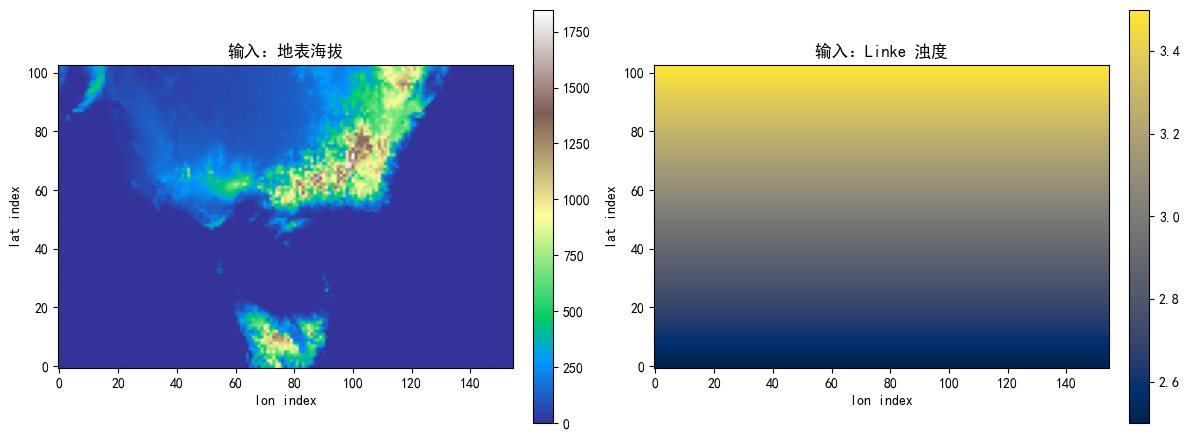

In [8]:
# 输入数据绘图：地表海拔与 Linke 浊度
clearsky_input_surface_altitude_2d = to_2d_values(surface_altitude_meb)
clearsky_input_linke_turbidity_2d = to_2d_values(linke_turbidity_meb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im0 = axes[0].imshow(clearsky_input_surface_altitude_2d, origin="lower", cmap="terrain")
axes[0].set_title("输入：地表海拔")
axes[0].set_xlabel("lon index")
axes[0].set_ylabel("lat index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(clearsky_input_linke_turbidity_2d, origin="lower", cmap="cividis")
axes[1].set_title("输入：Linke 浊度")
axes[1].set_xlabel("lon index")
axes[1].set_ylabel("lat index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


#### 3.3 输出对比绘图


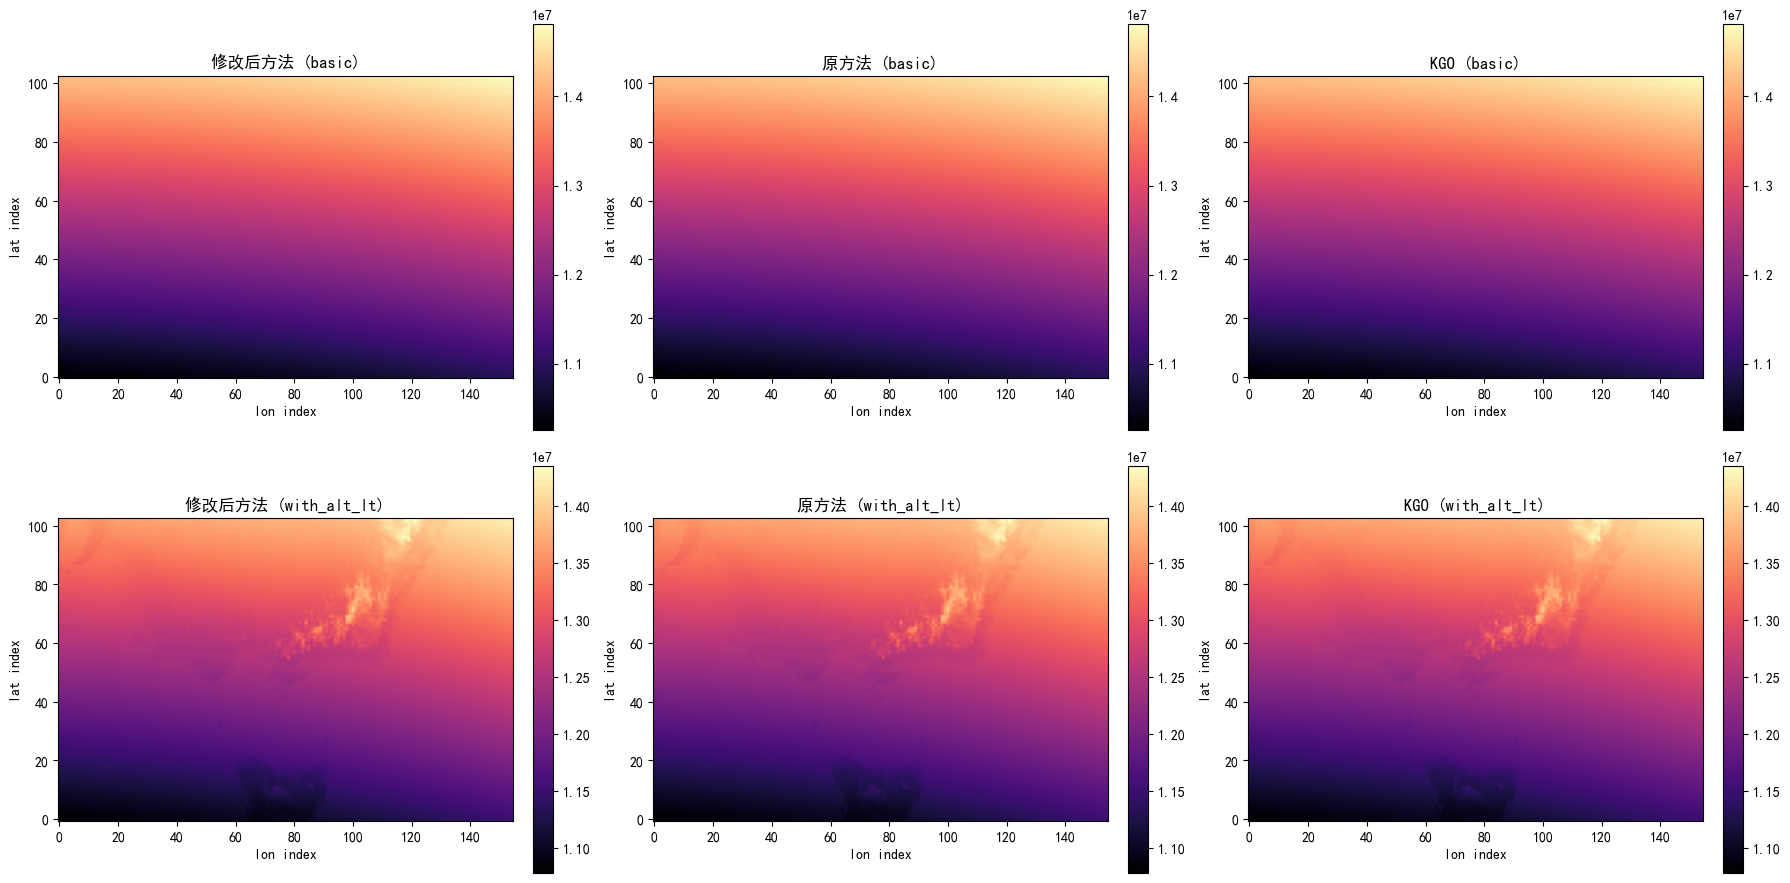

In [9]:
# 六图对比：
# 第一行是 basic 场景（修改后方法、原方法、KGO，统一色标）
# 第二行是 with_altitude_and_lt 场景（修改后方法、原方法、KGO，统一色标）
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

basic_vmin = float(np.nanmin([c_clear_basic.min(), o_clear_basic.min(), k_clear_basic.min()]))
basic_vmax = float(np.nanmax([c_clear_basic.max(), o_clear_basic.max(), k_clear_basic.max()]))

im00 = axes[0, 0].imshow(c_clear_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 0].set_title("修改后方法 (basic)")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

im01 = axes[0, 1].imshow(o_clear_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 1].set_title("原方法 (basic)")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

im02 = axes[0, 2].imshow(k_clear_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 2].set_title("KGO (basic)")
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04)

altlt_vmin = float(np.nanmin([c_clear_altlt.min(), o_clear_altlt.min(), k_clear_altlt.min()]))
altlt_vmax = float(np.nanmax([c_clear_altlt.max(), o_clear_altlt.max(), k_clear_altlt.max()]))

im10 = axes[1, 0].imshow(c_clear_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 0].set_title("修改后方法 (with_alt_lt)")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

im11 = axes[1, 1].imshow(o_clear_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 1].set_title("原方法 (with_alt_lt)")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

im12 = axes[1, 2].imshow(k_clear_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 2].set_title("KGO (with_alt_lt)")
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("lon index")
    ax.set_ylabel("lat index")

plt.tight_layout()
plt.show()


## 经纬坐标输入

本方案在预处理阶段对输入数据与 KGO 做投影→规则经纬重网格后再对比。

### 1. 数据预处理


In [10]:
from iris.coord_systems import GeogCS
from iris.coords import DimCoord
from iris.cube import Cube
from pyproj import CRS, Transformer

try:
    from scipy.interpolate import griddata
except Exception:
    griddata = None

# 经纬分支专用工具：将投影输入重网格到规则经纬网格，并在 xarray / iris 之间做桥接。
# 这里做的是“坐标转换 + 插值重网格”，用于与 KGO 严格数值可比验证。

def _regularize_axis(values: np.ndarray) -> np.ndarray:
    """将一维坐标规整为近似等间距，减少投影反算后的微小抖动。"""
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size < 2:
        return arr
    step = np.nanmedian(np.diff(arr))
    if not np.isfinite(step) or np.isclose(step, 0.0):
        return arr
    return arr[0] + step * np.arange(arr.size, dtype=np.float64)


def projected_da_to_regular_latlon_2d(data: xr.DataArray, *, method: str = "linear") -> xr.DataArray:
    """将投影二维场重网格到规则经纬二维场。"""
    arr = data
    for dim in list(arr.dims):
        if dim not in ("projection_y_coordinate", "projection_x_coordinate", "lat", "lon"):
            arr = arr.isel({dim: 0}, drop=True)

    if {"projection_y_coordinate", "projection_x_coordinate"}.issubset(set(arr.dims)):
        if griddata is None:
            raise ModuleNotFoundError("经纬分支严格可比验证需要 scipy.interpolate.griddata。")

        mapping_json = arr.attrs.get("grid_mapping_attrs")
        if not isinstance(mapping_json, str) or not mapping_json.strip():
            raise ValueError("缺少 grid_mapping_attrs，无法做投影转经纬重网格。")
        mapping_attrs = json.loads(mapping_json)

        # 源网格（投影）坐标
        y = np.asarray(arr.coords["projection_y_coordinate"].values, dtype=np.float64)
        x = np.asarray(arr.coords["projection_x_coordinate"].values, dtype=np.float64)
        yy, xx = np.meshgrid(y, x, indexing="ij")

        # 源网格每个格点对应的经纬坐标
        transformer = Transformer.from_crs(
            CRS.from_cf(mapping_attrs), CRS.from_epsg(4326), always_xy=True
        )
        lon2d_src, lat2d_src = transformer.transform(xx, yy)

        # 目标规则经纬网格
        lat_1d = _regularize_axis(np.nanmean(lat2d_src, axis=1))
        lon_1d = _regularize_axis(np.nanmean(lon2d_src, axis=0))
        lat2d_tgt, lon2d_tgt = np.meshgrid(lat_1d, lon_1d, indexing="ij")

        # 源值插值到规则经纬目标网格
        src_points = np.column_stack([lat2d_src.ravel(), lon2d_src.ravel()])
        src_values = np.asarray(arr.values, dtype=np.float64).ravel()
        tgt_points = np.column_stack([lat2d_tgt.ravel(), lon2d_tgt.ravel()])

        interp_values = griddata(src_points, src_values, tgt_points, method=method)

        # 线性插值边缘可能出现 NaN，用最近邻兜底补齐
        nan_mask = np.isnan(interp_values)
        if np.any(nan_mask):
            interp_nn = griddata(src_points, src_values, tgt_points, method="nearest")
            interp_values[nan_mask] = interp_nn[nan_mask]

        values_reg = interp_values.reshape(lat2d_tgt.shape)

        return xr.DataArray(
            values_reg.astype(np.float64),
            dims=("lat", "lon"),
            coords={"lat": lat_1d, "lon": lon_1d},
            name=str(arr.name or "field"),
            attrs={"units": str(arr.attrs.get("units", "1"))},
        )

    # 已经是经纬网格输入则直接规范维度
    if arr.dims != ("lat", "lon"):
        arr = arr.transpose("lat", "lon")
    return xr.DataArray(
        np.asarray(arr.values, dtype=np.float64),
        dims=("lat", "lon"),
        coords={
            "lat": np.asarray(arr.coords["lat"].values, dtype=np.float64),
            "lon": np.asarray(arr.coords["lon"].values, dtype=np.float64),
        },
        name=str(arr.name or "field"),
        attrs={"units": str(arr.attrs.get("units", "1"))},
    )


def build_meb6d_from_latlon(data_2d: xr.DataArray, *, name: str, time_value: str) -> xr.DataArray:
    """把经纬二维场封装成 meb 六维单场输入。"""
    values = data_2d.values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)
    attrs = {
        "model": "official_test_preprocessed_latlon",
        "dtime_units": "hour",
        "level_type": "surface",
        "time_type": "UT",
        "time_bounds": [0, 0],
        "units": str(data_2d.attrs.get("units", "1")),
        # 经纬输入无需 grid_mapping_attrs；缺省时方法按经纬处理
    }
    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": np.array([0], dtype=np.int32),
            "level": np.array([0], dtype=np.int32),
            "time": np.array([np.datetime64(time_value)], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": np.asarray(data_2d.coords["lat"].values, dtype=np.float64),
            "lon": np.asarray(data_2d.coords["lon"].values, dtype=np.float64),
        },
        attrs=attrs,
        name=name,
    )


def xr2d_to_iris_latlon_cube(data_2d: xr.DataArray, *, name: str, units: str):
    """将经纬二维 xarray 转成原方法可直接调用的 Iris Cube。"""
    cs = GeogCS(6378137.0)
    lat = DimCoord(
        np.asarray(data_2d.coords["lat"].values, dtype=np.float64),
        standard_name="latitude",
        units="degrees",
        coord_system=cs,
    )
    lon = DimCoord(
        np.asarray(data_2d.coords["lon"].values, dtype=np.float64),
        standard_name="longitude",
        units="degrees",
        coord_system=cs,
    )
    return Cube(
        np.asarray(data_2d.values, dtype=np.float32),
        long_name=name,
        units=units,
        dim_coords_and_dims=[(lat, 0), (lon, 1)],
        attributes={"source": "notebook-latlon-input-validation"},
    )


def iris_cube_to_xr2d(cube, *, name: str) -> xr.DataArray:
    """将原方法输出的 Iris Cube 转回经纬二维 xarray 以便统一比较。"""
    return xr.DataArray(
        np.asarray(cube.data, dtype=np.float64),
        dims=("lat", "lon"),
        coords={
            "lat": np.asarray(cube.coord(axis="y").points, dtype=np.float64),
            "lon": np.asarray(cube.coord(axis="x").points, dtype=np.float64),
        },
        name=name,
    )


In [11]:
# 经纬分支预处理：先把投影坐标输入重网格到规则经纬网格。
# 1) 读取并重网格业务输入场
solar_input_latlon = projected_da_to_regular_latlon_2d(
    load_primary_dataarray(solar_root / "surface_altitude.nc")
)
clearsky_surface_altitude_latlon = projected_da_to_regular_latlon_2d(
    load_primary_dataarray(clearsky_root / "surface_altitude.nc")
)
clearsky_linke_turbidity_latlon = projected_da_to_regular_latlon_2d(
    load_primary_dataarray(clearsky_root / "linke_turbidity.nc")
)

# 2) KGO 也重网格到同一经纬坐标，保证严格可比
solar_kgo_basic_latlon = projected_da_to_regular_latlon_2d(
    load_primary_dataarray(solar_root / "basic" / "kgo.nc")
)
clearsky_kgo_basic_latlon = projected_da_to_regular_latlon_2d(
    load_primary_dataarray(clearsky_root / "basic" / "kgo.nc")
)
clearsky_kgo_with_alt_lt_latlon = projected_da_to_regular_latlon_2d(
    load_primary_dataarray(clearsky_root / "with_altitude_and_lt" / "kgo.nc")
)

# 3) 将经纬二维场封装成 meb 六维，供修改后方法调用
solar_target_grid_latlon = build_meb6d_from_latlon(
    solar_input_latlon, name="target_grid", time_value=solar_valid_time
)
clearsky_target_grid_latlon = build_meb6d_from_latlon(
    clearsky_surface_altitude_latlon, name="target_grid", time_value=clearsky_valid_time
)
surface_altitude_meb_latlon = build_meb6d_from_latlon(
    clearsky_surface_altitude_latlon, name="surface_altitude", time_value=clearsky_valid_time
)
linke_turbidity_meb_latlon = build_meb6d_from_latlon(
    clearsky_linke_turbidity_latlon, name="linke_turbidity", time_value=clearsky_valid_time
)

# 4) 快速检查输入结构
print("solar_target_grid_latlon:", solar_target_grid_latlon.shape, solar_target_grid_latlon.dims)
print("clearsky_target_grid_latlon:", clearsky_target_grid_latlon.shape, clearsky_target_grid_latlon.dims)
solar_target_grid_latlon


solar_target_grid_latlon: (1, 1, 1, 1, 103, 155) ('member', 'level', 'time', 'dtime', 'lat', 'lon')
clearsky_target_grid_latlon: (1, 1, 1, 1, 103, 155) ('member', 'level', 'time', 'dtime', 'lat', 'lon')


<xarray.DataArray 'target_grid' (member: 1, level: 1, time: 1, dtime: 1,
                                 lat: 103, lon: 155)> Size: 64kB
array([[[[[[ 0.       ,  0.       ,  0.       , ...,  0.       ,
             0.       ,  0.       ],
           [ 0.       ,  0.       ,  0.       , ...,  0.       ,
             0.       ,  0.       ],
           [ 0.       ,  0.       ,  0.       , ...,  0.       ,
             0.       ,  0.       ],
           ...,
           [79.08072  ,  0.9917105,  0.       , ...,  0.       ,
             0.       ,  0.       ],
           [79.08072  ,  0.9917105,  0.       , ...,  0.       ,
             0.       ,  0.       ],
           [79.08072  ,  0.9917105,  0.       , ...,  0.       ,
             0.       ,  0.       ]]]]]],
      shape=(1, 1, 1, 1, 103, 155), dtype=float32)
Coordinates:
  * member   (member) int32 4B 0
  * level    (level) int32 4B 0
  * time     (time) datetime64[ns] 8B 2022-06-07
  * dtime    (dtime) int32 4B 0
  * lat      (lat) float64 824B -42.58 -42.5 -42.41 ... -33.93 -33.84 -33.76
  * lon      (lon) float64 1kB 137.8 137.9 138.1 138.2 ... 154.3 154.4 154.5
Attributes:
    model:        official_test_preprocessed_latlon
    dtime_units:  hour
    level_type:   surface
    time_type:    UT
    time_bounds:  [0, 0]
    units:        m

### 2. GenerateSolarTime


#### 2.1 算法运行与数值对比


In [12]:
# 修改后方法调用：使用经纬输入运行 SolarTime
solar_current_basic_latlon = GenerateSolarTime().process(
    target_grid=solar_target_grid_latlon,
    time=solar_valid_time_dt,
)

# 参数行为检查：new_title 透传到输出 attrs
solar_current_new_title_latlon = GenerateSolarTime().process(
    target_grid=solar_target_grid_latlon,
    time=solar_valid_time_dt,
    new_title="demo_new_title",
)
assert solar_current_new_title_latlon.attrs.get("title") == "demo_new_title"

# 原方法：在同一份经纬输入上调用，确保对比公平
orig_solar_plugin = OrigGenerateSolarTime()
solar_original_basic_latlon_cube = orig_solar_plugin.process(
    xr2d_to_iris_latlon_cube(solar_input_latlon, name="surface_altitude", units="m"),
    solar_valid_time_dt,
)
solar_original_basic_latlon = iris_cube_to_xr2d(
    solar_original_basic_latlon_cube, name="solar_original_basic_latlon"
)

# 指标对比：当前 vs KGO、当前 vs 原方法
c_solar2, k_solar2, d_solar2_ck = compare_stats(
    solar_current_basic_latlon, solar_kgo_basic_latlon, "solar 修改后方法-KGO"
)
_, o_solar2, d_solar2_co = compare_stats(
    solar_current_basic_latlon, solar_original_basic_latlon, "solar 修改后方法-原方法"
)
_,_,d_solar2_ok = compare_stats(
    solar_original_basic_latlon, solar_kgo_basic_latlon, "solar 原方法-KGO"
)


[solar 修改后方法-KGO] mean_abs=0.000314, max_abs=0.049898, rmse=0.002457
[solar 修改后方法-原方法] mean_abs=0.000000, max_abs=0.000001, rmse=0.000001
[solar 原方法-KGO] mean_abs=0.000314, max_abs=0.049898, rmse=0.002457


#### 2.2 输出对比绘图


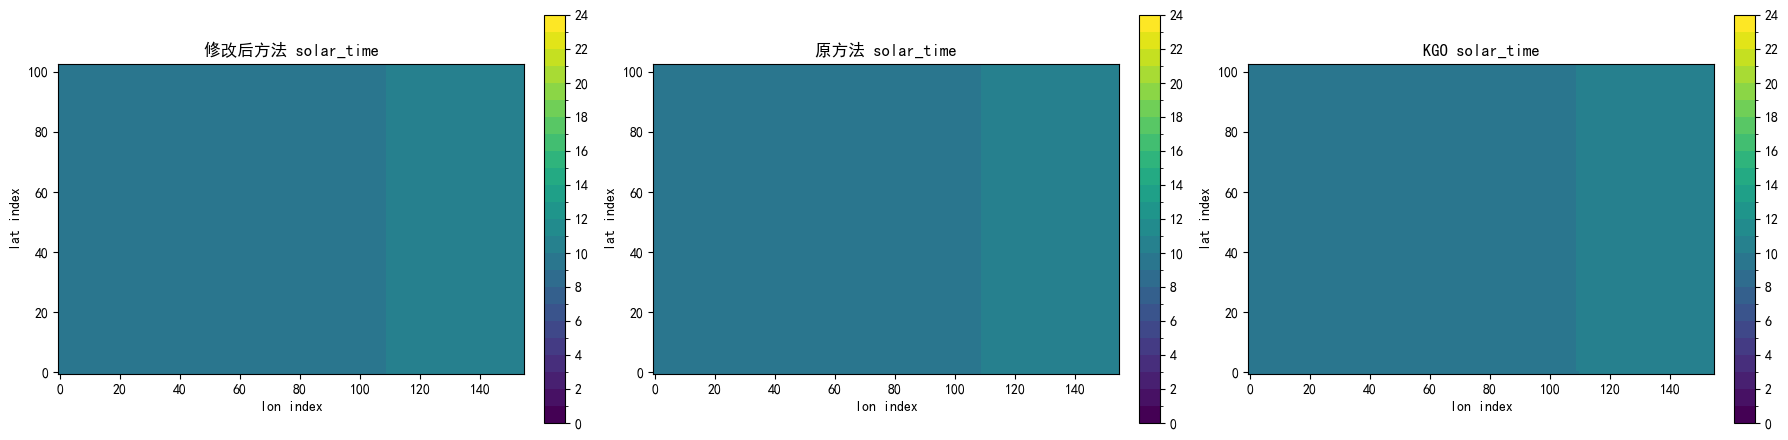

In [13]:
# 绘图对比：修改后方法 / 原方法 / KGO（统一色标，便于直观比较）
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# SolarTime 代表一天中的小时数，固定使用 0-24 分箱显示
solar_bounds = np.arange(0, 25, 1, dtype=np.float32)
solar_cmap = plt.get_cmap("viridis", len(solar_bounds) - 1)
solar_norm = BoundaryNorm(solar_bounds, solar_cmap.N, clip=True)
solar_ticks = np.arange(0, 25, 2, dtype=np.int32)

im0 = axes[0].imshow(c_solar2, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[0].set_title("修改后方法 solar_time")
axes[0].set_xlabel("lon index")
axes[0].set_ylabel("lat index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, ticks=solar_ticks)

im1 = axes[1].imshow(o_solar2, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[1].set_title("原方法 solar_time")
axes[1].set_xlabel("lon index")
axes[1].set_ylabel("lat index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, ticks=solar_ticks)

im2 = axes[2].imshow(k_solar2, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[2].set_title("KGO solar_time")
axes[2].set_xlabel("lon index")
axes[2].set_ylabel("lat index")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, ticks=solar_ticks)

plt.tight_layout()
plt.show()


### 3. GenerateClearskySolarRadiation


#### 3.1 算法运行与数值对比


In [14]:
# 从 KGO 的 time bounds 推断累积时长，保证同口径对比
acc_hours_latlon = infer_accumulation_hours_from_kgo(clearsky_root / "basic" / "kgo.nc")
print("inferred accumulation_period_hours :", acc_hours_latlon)

# 修改后方法调用：basic 场景
clearsky_current_basic_latlon = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid_latlon,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours_latlon,
)

# 修改后方法调用：with_altitude_and_lt 场景
clearsky_current_with_alt_lt_latlon = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid_latlon,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours_latlon,
    surface_altitude=surface_altitude_meb_latlon,
    linke_turbidity=linke_turbidity_meb_latlon,
)

clearsky_current_new_title_latlon = GenerateClearskySolarRadiation().process(
    target_grid=clearsky_target_grid_latlon,
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours_latlon,
    new_title="demo_new_title",
)
assert clearsky_current_new_title_latlon.attrs.get("title") == "demo_new_title"

# 原方法：同一份经纬输入下分别计算 basic 与 with_altitude_and_lt
orig_clearsky_plugin = OrigGenerateClearskySolarRadiation()
clearsky_original_basic_latlon_cube = orig_clearsky_plugin.process(
    target_grid=xr2d_to_iris_latlon_cube(clearsky_surface_altitude_latlon, name="surface_altitude", units="m"),
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours_latlon,
)
clearsky_original_with_alt_lt_latlon_cube = orig_clearsky_plugin.process(
    target_grid=xr2d_to_iris_latlon_cube(clearsky_surface_altitude_latlon, name="surface_altitude", units="m"),
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours_latlon,
    surface_altitude=xr2d_to_iris_latlon_cube(clearsky_surface_altitude_latlon, name="surface_altitude", units="m"),
    linke_turbidity=xr2d_to_iris_latlon_cube(clearsky_linke_turbidity_latlon, name="linke_turbidity", units="1"),
)

clearsky_original_basic_latlon = iris_cube_to_xr2d(
    clearsky_original_basic_latlon_cube, name="clearsky_original_basic_latlon"
)
clearsky_original_with_alt_lt_latlon = iris_cube_to_xr2d(
    clearsky_original_with_alt_lt_latlon_cube, name="clearsky_original_with_alt_lt_latlon"
)

# 指标对比：修改后方法 vs KGO、修改后方法 vs 原方法、原方法 vs KGO
c_clear_basic2, k_clear_basic2, _ = compare_stats(
    clearsky_current_basic_latlon, clearsky_kgo_basic_latlon, "clearsky basic 修改后方法-kgo"
)
_, o_clear_basic2, _ = compare_stats(
    clearsky_current_basic_latlon, clearsky_original_basic_latlon, "clearsky basic 修改后方法-原方法"
)
_, _, _ = compare_stats(
    clearsky_original_basic_latlon, clearsky_kgo_basic_latlon, "clearsky basic 原方法-KGO"
)

c_clear_altlt2, k_clear_altlt2, _ = compare_stats(
    clearsky_current_with_alt_lt_latlon,
    clearsky_kgo_with_alt_lt_latlon,
    "clearsky with_alt_lt 修改后方法-kgo",
)
_, o_clear_altlt2, _ = compare_stats(
    clearsky_current_with_alt_lt_latlon,
    clearsky_original_with_alt_lt_latlon,
    "clearsky with_alt_lt 修改后方法-原方法",
)
_, _, _ = compare_stats(
    clearsky_original_with_alt_lt_latlon,
    clearsky_kgo_with_alt_lt_latlon,
    "clearsky with_alt_lt 原方法-KGO",
)


inferred accumulation_period_hours : 24
[clearsky basic 修改后方法-kgo] mean_abs=4343.450268, max_abs=353885.000000, rmse=26300.679968
[clearsky basic 修改后方法-原方法] mean_abs=1.402192, max_abs=9.000000, rmse=1.846506
[clearsky basic 原方法-KGO] mean_abs=4343.164075, max_abs=353884.000000, rmse=26300.638163
[clearsky with_alt_lt 修改后方法-kgo] mean_abs=5241.776510, max_abs=360809.000000, rmse=26806.339670
[clearsky with_alt_lt 修改后方法-原方法] mean_abs=1.417914, max_abs=10.000000, rmse=1.869648
[clearsky with_alt_lt 原方法-KGO] mean_abs=5241.680182, max_abs=360810.000000, rmse=26806.290302


#### 3.2 输出对比绘图


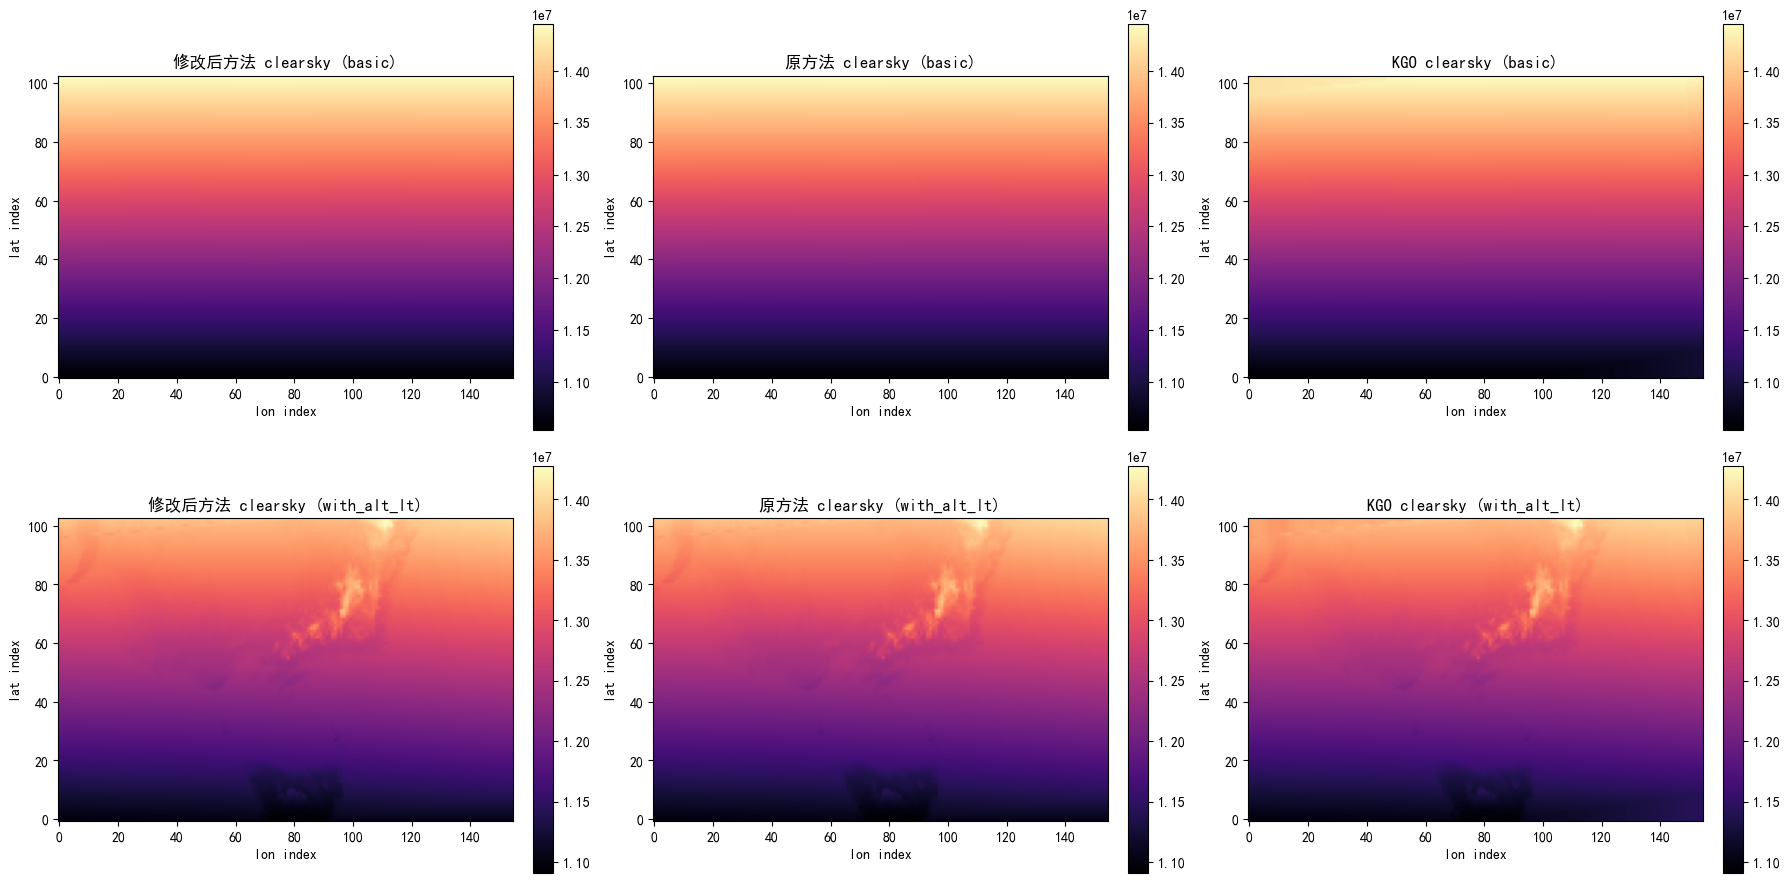

In [15]:
# 绘图对比：
# 第一行 basic（当前 / 原方法 / KGO，统一色标）
# 第二行 with_altitude_and_lt（当前 / 原方法 / KGO，统一色标）
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

basic_vmin = float(np.nanmin([c_clear_basic2.min(), o_clear_basic2.min(), k_clear_basic2.min()]))
basic_vmax = float(np.nanmax([c_clear_basic2.max(), o_clear_basic2.max(), k_clear_basic2.max()]))

im00 = axes[0, 0].imshow(c_clear_basic2, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 0].set_title("修改后方法 clearsky (basic)")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

im01 = axes[0, 1].imshow(o_clear_basic2, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 1].set_title("原方法 clearsky (basic)")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

im02 = axes[0, 2].imshow(k_clear_basic2, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 2].set_title("KGO clearsky (basic)")
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04)

altlt_vmin = float(np.nanmin([c_clear_altlt2.min(), o_clear_altlt2.min(), k_clear_altlt2.min()]))
altlt_vmax = float(np.nanmax([c_clear_altlt2.max(), o_clear_altlt2.max(), k_clear_altlt2.max()]))

im10 = axes[1, 0].imshow(c_clear_altlt2, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 0].set_title("修改后方法 clearsky (with_alt_lt)")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

im11 = axes[1, 1].imshow(o_clear_altlt2, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 1].set_title("原方法 clearsky (with_alt_lt)")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

im12 = axes[1, 2].imshow(k_clear_altlt2, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 2].set_title("KGO clearsky (with_alt_lt)")
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("lon index")
    ax.set_ylabel("lat index")

plt.tight_layout()
plt.show()


## CLI应用示例及结果对比

修改后 CLI 现场调用；原方法 CLI 读取 Improver 命令写出的 `cli_outputs/original_cli_*.nc`
（由仓库根目录 `_gen_original_cli.py` 生成）。


### 1. GenerateSolarTime

读取并对比三路结果：
- 修改后 CLI 结果（导入 `process` 调用）；
- 原方法 CLI 结果（`original_cli_solar_time.nc`，Improver `generate-solar-time`）；
- 官方 KGO（`basic/kgo.nc`）。


[solar cli 修改后方法-原方法] mean_abs=0.000000, max_abs=0.000002, rmse=0.000001
[solar cli 修改后方法-kgo] mean_abs=0.000000, max_abs=0.000002, rmse=0.000001
[solar cli 原方法-kgo] mean_abs=0.000000, max_abs=0.000000, rmse=0.000000


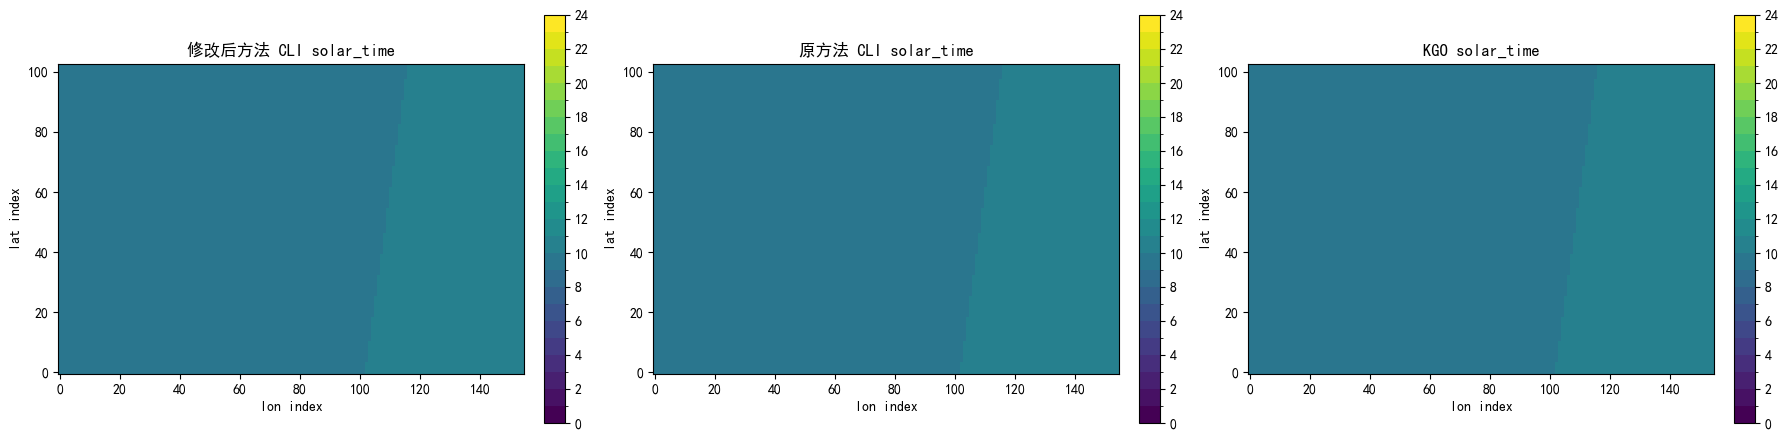

In [16]:
from generate_derived_solar_fields.cli.cal_generate_solar_time import process as cli_solar_process

solar_cli_root = TEST_ROOT / "generate-solar-time"
solar_cli_input = solar_cli_root / "cli_inputs" / "input_target_grid_meb.nc"
solar_cli_original_output = solar_cli_root / "cli_outputs" / "original_cli_solar_time.nc"
solar_kgo = solar_cli_root / "basic" / "kgo.nc"

# 修改后方法 CLI 结果（直接调用示例脚本中的 process）
solar_cli_current = cli_solar_process(
    target_grid_path=str(solar_cli_input),
    time=solar_valid_time_dt,
    output_path=None,
)

# 原方法 CLI 与 KGO 结果（直接读取 nc）
solar_cli_original = load_primary_dataarray(solar_cli_original_output)
solar_cli_kgo = load_primary_dataarray(solar_kgo)

# 数值统计
c_solar_cli, o_solar_cli, _ = compare_stats(
    solar_cli_current,
    solar_cli_original,
    "solar cli 修改后方法-原方法",
)
_, k_solar_cli, _ = compare_stats(
    solar_cli_current,
    solar_cli_kgo,
    "solar cli 修改后方法-kgo",
)
_, _, _ = compare_stats(
    solar_cli_original,
    solar_cli_kgo,
    "solar cli 原方法-kgo",
)

# 三图统一色标对比
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

solar_bounds = np.arange(0, 25, 1, dtype=np.float32)
solar_cmap = plt.get_cmap("viridis", len(solar_bounds) - 1)
solar_norm = BoundaryNorm(solar_bounds, solar_cmap.N, clip=True)
solar_ticks = np.arange(0, 25, 2, dtype=np.int32)

im0 = axes[0].imshow(c_solar_cli, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[0].set_title("修改后方法 CLI solar_time")
axes[0].set_xlabel("lon index")
axes[0].set_ylabel("lat index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, ticks=solar_ticks)

im1 = axes[1].imshow(o_solar_cli, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[1].set_title("原方法 CLI solar_time")
axes[1].set_xlabel("lon index")
axes[1].set_ylabel("lat index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, ticks=solar_ticks)

im2 = axes[2].imshow(k_solar_cli, origin="lower", cmap=solar_cmap, norm=solar_norm)
axes[2].set_title("KGO solar_time")
axes[2].set_xlabel("lon index")
axes[2].set_ylabel("lat index")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, ticks=solar_ticks)

plt.tight_layout()
plt.show()


### 2. GenerateClearskySolarRadiation

在 `basic` 与 `with_altitude_and_lt` 两场景下分别对比：
- 修改后 CLI 结果（导入 `process` 调用）；
- 原方法 CLI 结果（Improver `generate-clearsky-solar-radiation`）；
- 官方 KGO。


[clearsky cli basic 修改后方法-原方法] mean_abs=1.433573, max_abs=8.000000, rmse=1.878505
[clearsky cli basic 修改后方法-kgo] mean_abs=1.433573, max_abs=8.000000, rmse=1.878505
[clearsky cli basic 原方法-kgo] mean_abs=0.000000, max_abs=0.000000, rmse=0.000000
[clearsky cli with_alt_lt 修改后方法-原方法] mean_abs=273.572628, max_abs=556.000000, rmse=317.553563
[clearsky cli with_alt_lt 修改后方法-kgo] mean_abs=273.572628, max_abs=556.000000, rmse=317.553563
[clearsky cli with_alt_lt 原方法-kgo] mean_abs=0.000000, max_abs=0.000000, rmse=0.000000


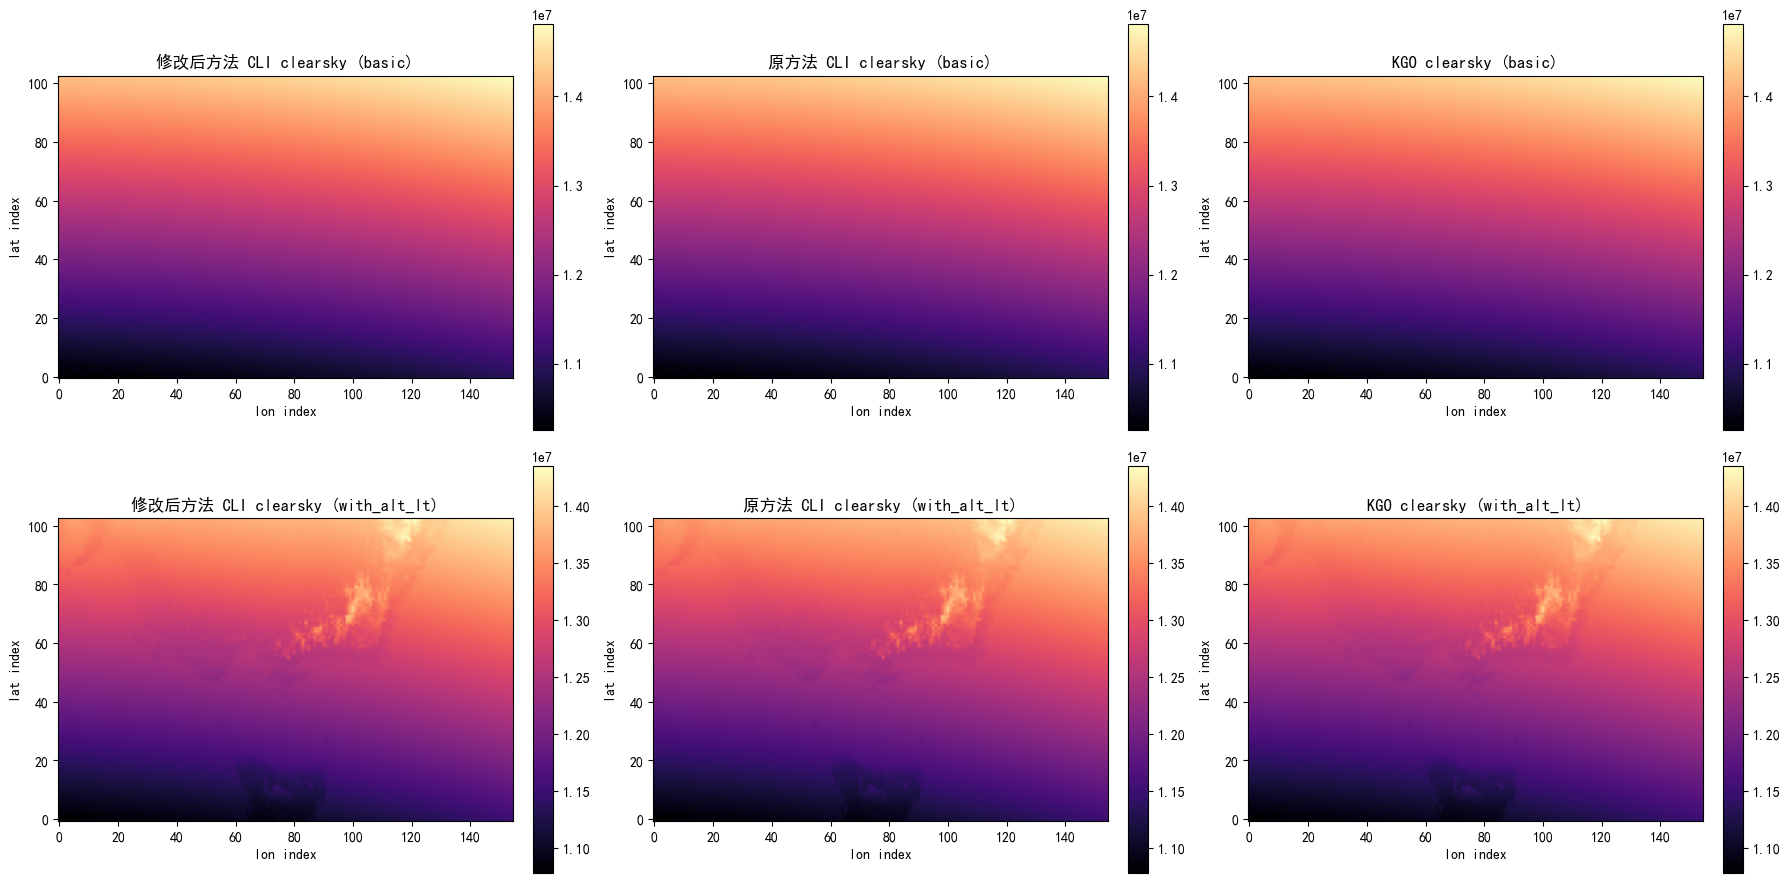

In [17]:
from generate_derived_solar_fields.cli.cal_generate_clearsky_solar_radiation import (
    process as cli_clearsky_process,
)

clearsky_cli_root = TEST_ROOT / "generate-clearsky-solar-radiation"
clearsky_cli_input_root = clearsky_cli_root / "cli_inputs"
clearsky_cli_output_root = clearsky_cli_root / "cli_outputs"

surface_altitude_path = clearsky_cli_input_root / "input_surface_altitude_meb.nc"
linke_turbidity_path = clearsky_cli_input_root / "input_linke_turbidity_meb.nc"
acc_hours_cli = infer_accumulation_hours_from_kgo(clearsky_cli_root / "basic" / "kgo.nc")

# 修改后方法 结果：basic
clearsky_cli_current_basic = cli_clearsky_process(
    target_grid_path=str(surface_altitude_path),
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours_cli,
    output_path=None,
)

# 修改后方法 CLI 结果：with_altitude_and_lt
clearsky_cli_current_altlt = cli_clearsky_process(
    target_grid_path=str(surface_altitude_path),
    time=clearsky_valid_time_dt,
    accumulation_period=acc_hours_cli,
    surface_altitude_path=str(surface_altitude_path),
    linke_turbidity_path=str(linke_turbidity_path),
    output_path=None,
)

# 原方法 CLI 输出
clearsky_cli_original_basic = load_primary_dataarray(
    clearsky_cli_output_root / "original_cli_clearsky_basic.nc"
)
clearsky_cli_original_altlt = load_primary_dataarray(
    clearsky_cli_output_root / "original_cli_clearsky_with_alt_lt.nc"
)

# KGO
clearsky_cli_kgo_basic = load_primary_dataarray(clearsky_cli_root / "basic" / "kgo.nc")
clearsky_cli_kgo_altlt = load_primary_dataarray(
    clearsky_cli_root / "with_altitude_and_lt" / "kgo.nc"
)

# 数值统计
c_clear_cli_basic, o_clear_cli_basic, _ = compare_stats(
    clearsky_cli_current_basic,
    clearsky_cli_original_basic,
    "clearsky cli basic 修改后方法-原方法",
)
_, k_clear_cli_basic, _ = compare_stats(
    clearsky_cli_current_basic,
    clearsky_cli_kgo_basic,
    "clearsky cli basic 修改后方法-kgo",
)
_, _, _ = compare_stats(
    clearsky_cli_original_basic,
    clearsky_cli_kgo_basic,
    "clearsky cli basic 原方法-kgo",
)

c_clear_cli_altlt, o_clear_cli_altlt, _ = compare_stats(
    clearsky_cli_current_altlt,
    clearsky_cli_original_altlt,
    "clearsky cli with_alt_lt 修改后方法-原方法",
)
_, k_clear_cli_altlt, _ = compare_stats(
    clearsky_cli_current_altlt,
    clearsky_cli_kgo_altlt,
    "clearsky cli with_alt_lt 修改后方法-kgo",
)
_, _, _ = compare_stats(
    clearsky_cli_original_altlt,
    clearsky_cli_kgo_altlt,
    "clearsky cli with_alt_lt 原方法-kgo",
)

# 三图对比（两行场景）
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

basic_vmin = float(
    np.nanmin([c_clear_cli_basic.min(), o_clear_cli_basic.min(), k_clear_cli_basic.min()])
)
basic_vmax = float(
    np.nanmax([c_clear_cli_basic.max(), o_clear_cli_basic.max(), k_clear_cli_basic.max()])
)

im00 = axes[0, 0].imshow(c_clear_cli_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 0].set_title("修改后方法 CLI clearsky (basic)")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046, pad=0.04)

im01 = axes[0, 1].imshow(o_clear_cli_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 1].set_title("原方法 CLI clearsky (basic)")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046, pad=0.04)

im02 = axes[0, 2].imshow(k_clear_cli_basic, origin="lower", cmap="magma", vmin=basic_vmin, vmax=basic_vmax)
axes[0, 2].set_title("KGO clearsky (basic)")
plt.colorbar(im02, ax=axes[0, 2], fraction=0.046, pad=0.04)

altlt_vmin = float(
    np.nanmin([c_clear_cli_altlt.min(), o_clear_cli_altlt.min(), k_clear_cli_altlt.min()])
)
altlt_vmax = float(
    np.nanmax([c_clear_cli_altlt.max(), o_clear_cli_altlt.max(), k_clear_cli_altlt.max()])
)

im10 = axes[1, 0].imshow(c_clear_cli_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 0].set_title("修改后方法 CLI clearsky (with_alt_lt)")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046, pad=0.04)

im11 = axes[1, 1].imshow(o_clear_cli_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 1].set_title("原方法 CLI clearsky (with_alt_lt)")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046, pad=0.04)

im12 = axes[1, 2].imshow(k_clear_cli_altlt, origin="lower", cmap="magma", vmin=altlt_vmin, vmax=altlt_vmax)
axes[1, 2].set_title("KGO clearsky (with_alt_lt)")
plt.colorbar(im12, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xlabel("lon index")
    ax.set_ylabel("lat index")

plt.tight_layout()
plt.show()
